In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram

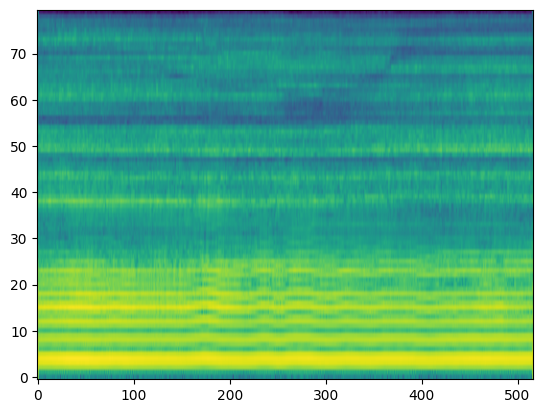

In [2]:
path = "/Users/llukii/Desktop/School/Programming/Multimodal throat cancer/dataset/0C02umg.wav.spec.npy"
spectrogram = np.load(path)
plt.imshow(spectrogram, aspect='auto', origin='lower')

In [3]:
spectrogram.shape

(80, 517)

In [ ]:
mel_args = {
      'sample_rate': 16000,
      'win_length': 256 * 4,
      'hop_length': 256,
      'n_fft': 1024,
      'f_min': 20.0,
      'f_max': 16000 / 2.0,
      'n_mels': 80,
      'power': 1.0,
      'normalized': True,
}

mel_spectrogram_conv = MelSpectrogram(**mel_args)
raw_audio = np.random.randn(1, 48000) # x_T
spectrogram = mel_spectrogram_conv(torch.tensor(raw_audio, dtype=torch.float32))
spectrogram = 20 * torch.log10(torch.clamp(spectrogram, min=1e-5)) - 20
spectrogram = torch.clamp((spectrogram + 100) / 100, 0.0, 1.0)
np.save("/Users/llukii/Desktop/School/Programming/Multimodal throat cancer/dataset/test_mel_spectrogram.npy", spectrogram.numpy())

In [10]:
spectrogram.shape

torch.Size([1, 80, 188])

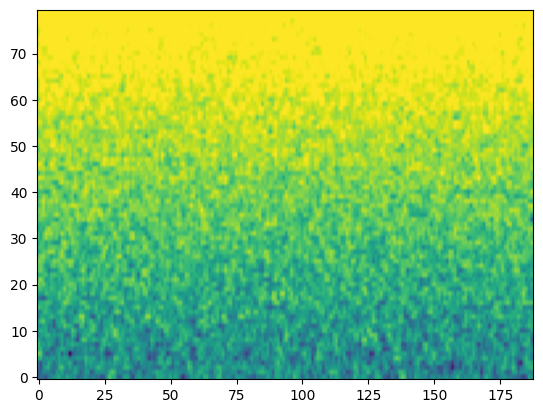

In [11]:
plt.imshow(spectrogram.numpy()[0], aspect='auto', origin='lower')